In [66]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Investigating Exclusion of Counties that have Existing Plants

In [56]:
final_data = Path.cwd().parent.joinpath('processed_data', 'final_dataset.csv')
candidates_data = Path.cwd().parent.joinpath('processed_data', 'candidates.csv')

In [57]:
# reading final_dataset.csv and candidates.csv
df_final = pd.read_csv(final_data)
df_candidates = pd.read_csv(candidates_data)

In [58]:
# motivating validation more . . .
# identifying plants that survived or were excluded by masking
has_plant = df_final[df_final['plant_count'] > 0]
survived = has_plant[has_plant['geo_id'].isin(df_candidates['geo_id'])]
excluded = has_plant[~has_plant['geo_id'].isin(df_candidates['geo_id'])]

print(f'Plant counties in full dataset: {len(has_plant)}')
print(f'Plant counties surviving masking: {len(survived)}')
print(f'Plant counties excluded by maksing: {len(excluded)}')

Plant counties in full dataset: 54
Plant counties surviving masking: 42
Plant counties excluded by maksing: 12


In [59]:
# finding exclusion reasons
def exclusion_reason(county):
    reasons = []
    if county['pga_max'] > 0.3:
        reasons.append(f'seismic (pga_max={county['pga_max']:.4f})')
    if county['pct_sfha'] > 0.2:
        reasons.append(f'flood (pct_sfha={county['pct_sfha']:.4f})')
    if county['pct_military'] > 0.1:
        reasons.append(f'military (pct_military={county['pct_military']:.4f})')
    if county['pct_protected'] > 0.1:
        reasons.append(f'protected (pct_protected={county['pct_protected']:.4f})')
    return ', '.join(reasons)

excluded = excluded.copy()
excluded['exclusion_reason'] = excluded.apply(exclusion_reason, axis=1)
with pd.option_context('display.max_colwidth', None):
    display(excluded[['county_name', 'exclusion_reason']])

,county_name,exclusion_reason
118,Matagorda County,flood (pct_sfha=0.4517)
464,Coffey County,flood (pct_sfha=0.2101)
691,West Feliciana Parish,flood (pct_sfha=0.3915)
926,Claiborne County,flood (pct_sfha=0.2020)
939,Miami-Dade County,"flood (pct_sfha=0.4680), protected (pct_protected=0.4706)"
1779,San Luis Obispo County,"seismic (pga_max=0.5300), protected (pct_protected=0.1626)"
1918,Maricopa County,"military (pct_military=0.1233), protected (pct_protected=0.1393)"
2197,Brunswick County,flood (pct_sfha=0.3282)
2582,Nemaha County,flood (pct_sfha=0.2122)
2849,Hamilton County,seismic (pga_max=0.3200)


In [60]:
exclusion_counts = {'Seismic': (has_plant['pga_max'] > 0.3).sum(),
                    'Flood': (has_plant['pct_sfha'] > 0.2).sum(),
                    'Military': (has_plant['pct_military'] > 0.1).sum(),
                    'Protected': (has_plant['pct_protected'] > 0.1).sum()}
exclusion_counts

{'Seismic': 2, 'Flood': 9, 'Military': 1, 'Protected': 4}

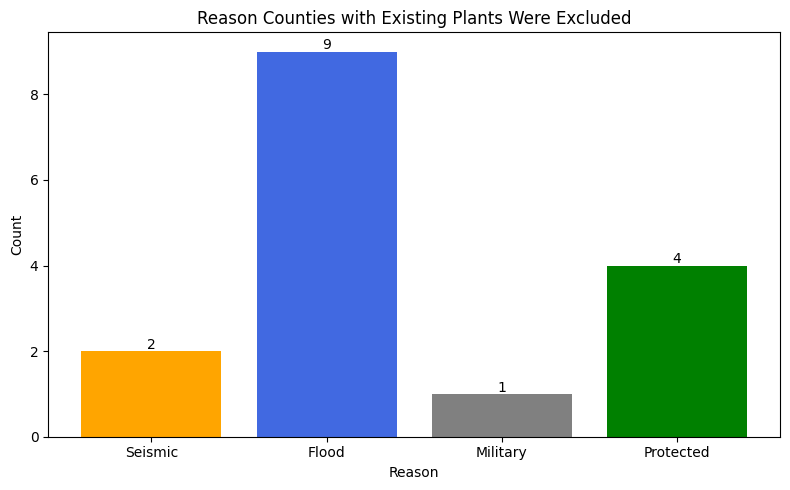

In [61]:
# bar graph of count of reasons why counties with existing plants were excluded

plt.figure(figsize=(8, 5))
plt.bar(exclusion_counts.keys(), exclusion_counts.values(), color=['orange', 'royalblue', 'gray', 'green'])
plt.title('Reason Counties with Existing Plants Were Excluded')
plt.ylabel('Count')
plt.xlabel('Reason')
for i, (k, v) in enumerate(exclusion_counts.items()):
    plt.text(i, v + 0.05, str(v), ha='center')
plt.tight_layout()
plt.show()

## Extracting Feature Importance

In [62]:
candidates_ranked_data = Path.cwd().parent.joinpath('processed_data', 'candidates_ranked.csv')
candidates_ranked_data

WindowsPath('c:/Users/brian/OneDrive - University of Illinois - Urbana/team-nuclear-family/processed_data/candidates_ranked.csv')

In [63]:
df = pd.read_csv(candidates_ranked_data)
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671,1880.0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694,1349.0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095,799.0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314,1404.0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162,1284.0


In [71]:
# from scoring.ipynb:
# some variables are better if they have a higher value
# while others are better if they have a lower value

higher_better = [
    "avg_vol",
    "total_lake_area", 
    "max_voltage",
    "total_energy_consumption_mwh",
    "data_centers_count"
]

lower_better = [
    "pga_max",
    "pct_sfha",
    "population_density",
    "dist_to_lakes_km",
    "distance_to_lines_km",
    "pct_military",
    "pct_protected",
]

scored_features = higher_better + lower_better
scored_features

['avg_vol',
 'total_lake_area',
 'max_voltage',
 'total_energy_consumption_mwh',
 'data_centers_count',
 'pga_max',
 'pct_sfha',
 'population_density',
 'dist_to_lakes_km',
 'distance_to_lines_km',
 'pct_military',
 'pct_protected']

In [73]:
# places with no mcda_score
df[df['mcda_score'].isna()]

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
155,78030,St. Thomas Island,NaN,NaN,NaN,NaN,0.0,4.057066e+07,0.050775,1,...,0.0,0.000000,20.0,2.299731e+06,0.002878,799.030691,NaN,0,NaN,NaN
226,60040,Swains Island,NaN,NaN,NaN,NaN,0.0,0.000000e+00,0.000000,1,...,0.0,0.000000,0.0,0.000000e+00,0.000000,151.603053,NaN,0,NaN,NaN
297,66010,Guam,NaN,NaN,NaN,NaN,0.0,9.705555e+07,0.065672,1,...,0.0,0.000000,13.0,1.108224e+08,0.074987,1477.893555,NaN,0,NaN,NaN
325,69100,Rota Municipality,NaN,NaN,NaN,NaN,0.0,4.917306e+06,0.007878,0,...,0.0,0.000000,0.0,0.000000e+00,0.000000,624.189588,NaN,0,NaN,NaN
846,69110,Saipan Municipality,NaN,NaN,NaN,NaN,0.0,1.852848e+07,0.028433,1,...,0.0,0.000000,0.0,0.000000e+00,0.000000,651.656085,NaN,0,NaN,NaN
854,9110,Capitol Planning Region,994115.0,88190.0,413960.0,NaN,1.0,1.954939e+08,0.072148,53,...,345.0,141.285714,1114.0,1.005055e+08,0.037092,2709.608749,366.885072,0,NaN,NaN
855,9120,Greater Bridgeport Planning Region,337697.0,83147.0,125378.0,NaN,1.0,6.009566e+07,0.097426,10,...,345.0,125.000000,73.0,1.494759e+07,0.024233,616.832049,547.469932,0,NaN,NaN
856,9130,Lower Connecticut River Valley Planning Region,177311.0,99742.0,82618.0,NaN,0.0,1.643571e+08,0.122696,35,...,345.0,191.666667,711.0,8.471923e+07,0.063245,1339.543612,132.366724,0,NaN,NaN
857,9140,Naugatuck Valley Planning Region,463349.0,82939.0,191666.0,NaN,0.0,4.851334e+07,0.044432,30,...,345.0,119.893617,337.0,3.754786e+07,0.034389,1091.854238,424.368917,0,NaN,NaN
858,9150,Northeastern Connecticut Planning Region,98096.0,83119.0,41503.0,NaN,0.0,6.902615e+07,0.047325,47,...,345.0,161.000000,192.0,4.674583e+07,0.032049,1458.569142,67.254954,0,NaN,NaN


In [74]:
# dropping places with no mcda_score
df = df.dropna(subset=['mcda_score'])
print(f'Total candidates: {len(df)}')
print(f'Has plant: {df["has_plant"].sum()}')
print(f'No plant:  {(df["has_plant"]==0).sum()}')

Total candidates: 2141
Has plant: 41
No plant:  2100


Southeastern Connecticut Planning Region, which has an operating nuclear plant, was dropped as it does not have an mcda_score due to no total energy consumption data for it in our dataset. This can be something to investigate.

getting to validation soon